# Unsupervised Learning — Hands-On Lab
### Dlytica · Data Science & AI/ML Professional

**Companion notebook for the Unsupervised Learning class.**

In this lab you will:
1. Implement **K-Means** from scratch, then use scikit-learn (elbow method, silhouette score, feature scaling)
2. Apply **DBSCAN** and tune `eps` / `min_samples` with the k-distance plot
3. Implement **PCA** with NumPy, verify against scikit-learn, and apply it to the Iris dataset
4. Bonus mini-project: **customer segmentation** (K-Means + PCA together)

> Everything runs offline — datasets are either synthetic (`make_blobs`, `make_moons`) or built into scikit-learn (Iris).

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
print("Setup complete")

Setup complete


---
## Part 1 — K-Means Clustering

### 1.1 Create a dataset

`make_blobs` gives us Gaussian blobs — the ideal case for K-Means. We generate 4 blobs but pretend we don't know that (unsupervised!).

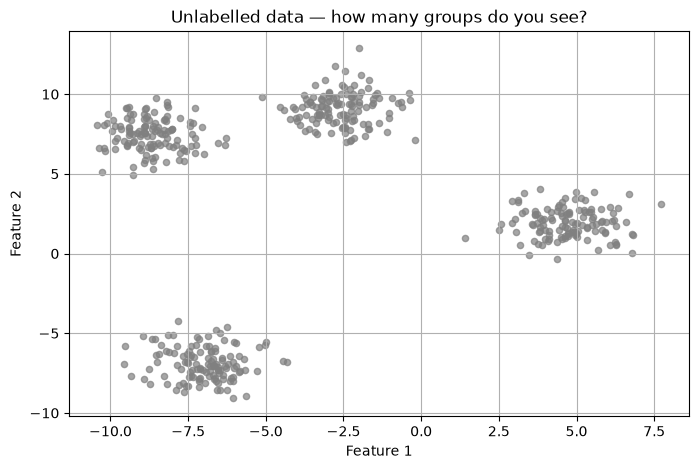

In [2]:
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=20, c="gray", alpha=0.7)
plt.title("Unlabelled data — how many groups do you see?")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()

### 1.2 K-Means from scratch

The algorithm in ~25 lines. Two steps repeated until nothing changes:
- **Assign**: each point goes to its nearest centroid
- **Update**: each centroid moves to the mean of its points

In [ ]:
def kmeans_scratch(X, k, max_iters=100, seed=0):
    """Minimal K-Means: returns (labels, centroids, n_iterations)."""
    rng = np.random.RandomState(seed)
    # 1. Initialise: pick k random data points as starting centroids
    centroids = X[rng.choice(len(X), k, replace=False)]

    for iteration in range(max_iters):
        # 2. Assign: distance of every point to every centroid -> nearest wins
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)  # (n, k)
        labels = distances.argmin(axis=1)

        # 3. Update: move each centroid to the mean of its assigned points
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])

        # 4. Converged? centroids stopped moving
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids

    return labels, centroids, iteration + 1

labels, centroids, n_iter = kmeans_scratch(X, k=4)
print(f"Converged in {n_iter} iterations")

plt.scatter(X[:, 0], X[:, 1], s=20, c=labels, cmap="viridis", alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=250, c="red",
            edgecolors="white", linewidths=2, label="Centroids")
plt.title("K-Means from scratch (k = 4)"); plt.legend()
plt.show()

### 1.3 K-Means with scikit-learn

In practice use `sklearn.cluster.KMeans`. Two important defaults:
- `init="k-means++"` — spreads initial centroids apart (avoids bad local minima)
- `n_init=10` — runs 10 restarts and keeps the one with lowest inertia

Inertia (WCSS): 3426.3
Iterations: 3
Centroids:
[[ 4.72  1.92]
 [-5.64  8.27]
 [-7.   -6.9 ]]


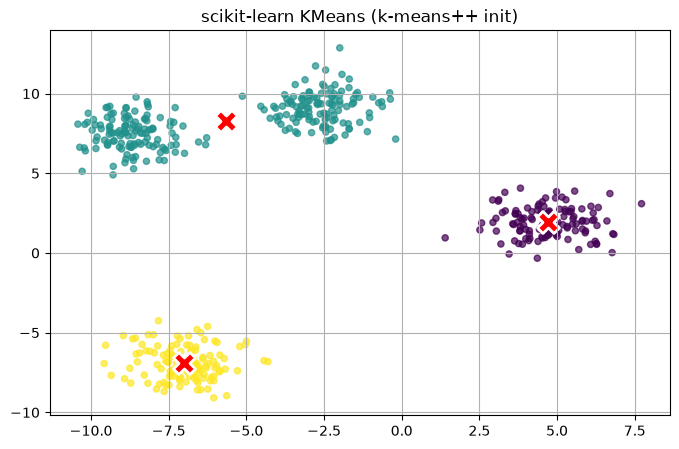

In [5]:
km = KMeans(n_clusters=3, init="k-means++", n_init=2, random_state=42)
labels_sk = km.fit_predict(X)

print(f"Inertia (WCSS): {km.inertia_:.1f}")
print(f"Iterations: {km.n_iter_}")
print(f"Centroids:\n{km.cluster_centers_.round(2)}")

plt.scatter(X[:, 0], X[:, 1], s=20, c=labels_sk, cmap="viridis", alpha=0.7)
plt.scatter(*km.cluster_centers_.T, marker="X", s=250, c="red",
            edgecolors="white", linewidths=2)
plt.title("scikit-learn KMeans (k-means++ init)")
plt.show()

### 1.4 Choosing k — elbow method + silhouette score

Two tools used together to find the right number of clusters:

---

#### Elbow method (Inertia / J)

**What it is:** J = total squared distance of every point to its own centroid. sklearn calls this `inertia_`.

**What it tells you:** smaller J = tighter clusters = better. But J *always* drops as k grows — at k = n_samples every point is its own centroid and J = 0. So J alone cannot pick k.

**How to use it:** plot J vs k and look for the **bend (elbow)** — the point where J stops dropping sharply and flattens out. Adding more clusters beyond the elbow gives almost no improvement in tightness.

```
J
|*
| *
|   *
|      *  ← elbow here
|         * * * * *  ← flat, no real gain
+--------------------→ k
```

---

#### Silhouette score (s)

**What it measures:** is each point in the *right* cluster? Not just tight, but also well-separated from other clusters.

**For each point, compute:**
- `a` = average distance to all other points in its **own** cluster (cohesion — smaller = better)
- `b` = average distance to all points in the **nearest other** cluster (separation — larger = better)

$$s = \frac{b - a}{\max(a, b)}$$

**Reading the result:**

| Score | Meaning |
|-------|---------|
| Close to **+1** | Point sits deep inside its cluster, far from others — perfect |
| Around **0** | Point is on the boundary — could belong to either cluster |
| **Negative** | Point is closer to another cluster — likely misclassified |

**How to use it:** average s across all points for each k. Pick k at the **peak** — that is the k where points are best assigned to their clusters.

> **Rule of thumb:** use both. If they agree → confident answer. If they disagree → use domain knowledge to break the tie.

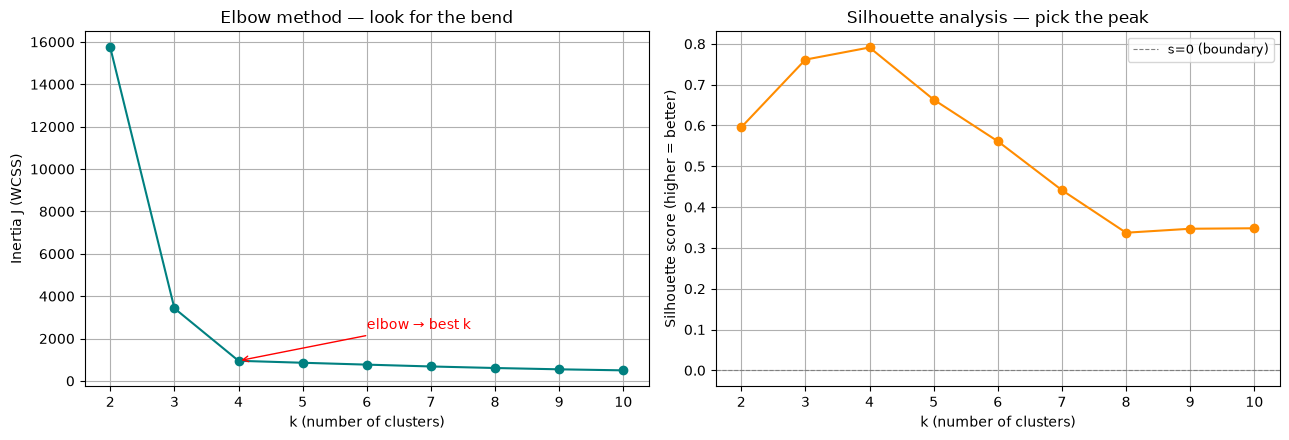

Best k by silhouette: 4
Silhouette score at k=4: 0.791

Interpretation guide:
  s > 0.5  → strong cluster structure
  s = 0.25-0.5 → moderate structure
  s < 0.25 → weak structure — clusters may not be meaningful


In [6]:
ks = range(2, 11)
inertias, silhouettes = [], []

for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km_k.inertia_)           # J = total squared distance to centroids
    silhouettes.append(silhouette_score(X, km_k.labels_))  # avg s across all points

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Elbow plot ---
axes[0].plot(list(ks), inertias, "-o", color="teal")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia J (WCSS)")
axes[0].set_title("Elbow method — look for the bend")
# Annotate the elbow
axes[0].annotate("elbow → best k",
    xy=(4, inertias[2]), xytext=(6, inertias[2] + 1500),
    arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=10)

# --- Silhouette plot ---
axes[1].plot(list(ks), silhouettes, "-o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score (higher = better)")
axes[1].set_title("Silhouette analysis — pick the peak")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8, label="s=0 (boundary)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette: {best_k}")
print(f"Silhouette score at k={best_k}: {max(silhouettes):.3f}")
print()
print("Interpretation guide:")
print("  s > 0.5  → strong cluster structure")
print("  s = 0.25-0.5 → moderate structure")
print("  s < 0.25 → weak structure — clusters may not be meaningful")

### 1.5 Why feature scaling matters

Distance-based algorithms are dominated by whichever feature has the biggest range. Watch K-Means fail on unscaled data, then get rescued by `StandardScaler`.

In [ ]:
# Two clear groups, but 'income' is 1000x the scale of 'age'
rng = np.random.RandomState(0)
age    = np.r_[rng.normal(28, 3, 150), rng.normal(55, 4, 150)]
income = np.r_[rng.normal(40_000, 8_000, 150), rng.normal(42_000, 8_000, 150)]
X_unscaled = np.c_[age, income]

lab_raw    = KMeans(2, n_init=10, random_state=0).fit_predict(X_unscaled)
X_scaled   = StandardScaler().fit_transform(X_unscaled)
lab_scaled = KMeans(2, n_init=10, random_state=0).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(age, income, c=lab_raw, cmap="coolwarm", s=15)
axes[0].set_title("Unscaled: income drowns out age → wrong split")
axes[1].scatter(age, income, c=lab_scaled, cmap="coolwarm", s=15)
axes[1].set_title("StandardScaler first: correct age groups found")
for ax in axes:
    ax.set_xlabel("Age"); ax.set_ylabel("Income")
plt.show()

---
## Part 2 — DBSCAN

### 2.1 Where K-Means fails: the two moons

DBSCAN groups points by **density**: a cluster is a dense region separated by sparse regions.

Key parameters:
- `eps` (ε): neighbourhood radius
- `min_samples` (minPts): points needed inside ε for a point to be a **core** point

Points reachable from no core point are labelled **noise** (`-1`).

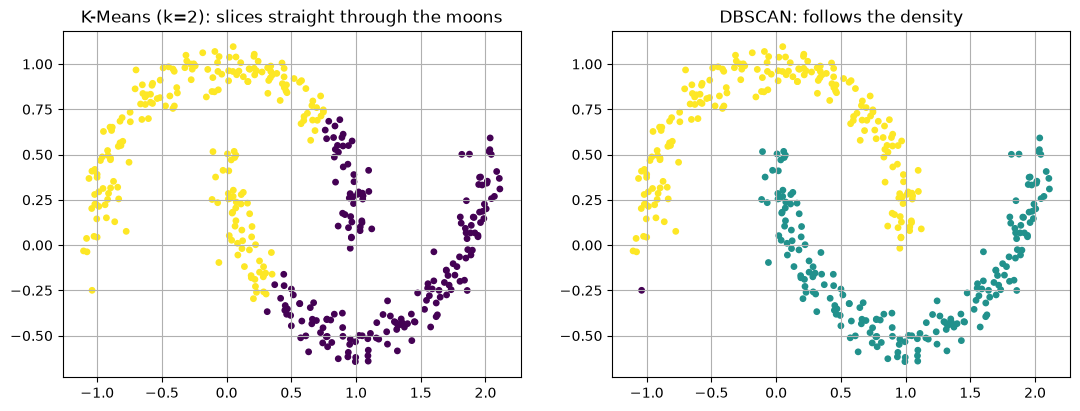

DBSCAN found 2 clusters and 1 noise points (label -1)


In [7]:
X_moons, _ = make_moons(n_samples=400, noise=0.07, random_state=42)

km_moons = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_moons)
db_moons = DBSCAN(eps=0.18, min_samples=5).fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(*X_moons.T, c=km_moons, cmap="viridis", s=15)
axes[0].set_title("K-Means (k=2): slices straight through the moons")
axes[1].scatter(*X_moons.T, c=db_moons, cmap="viridis", s=15)
axes[1].set_title("DBSCAN: follows the density")
plt.show()

n_clusters = len(set(db_moons)) - (1 if -1 in db_moons else 0)
n_noise = int((db_moons == -1).sum())
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points (label -1)")

### 2.2 Choosing ε: the k-distance plot

Compute each point's distance to its k-th nearest neighbour (k = `min_samples`), sort ascending, and look for the **knee** — the point where distances jump. That's your ε.

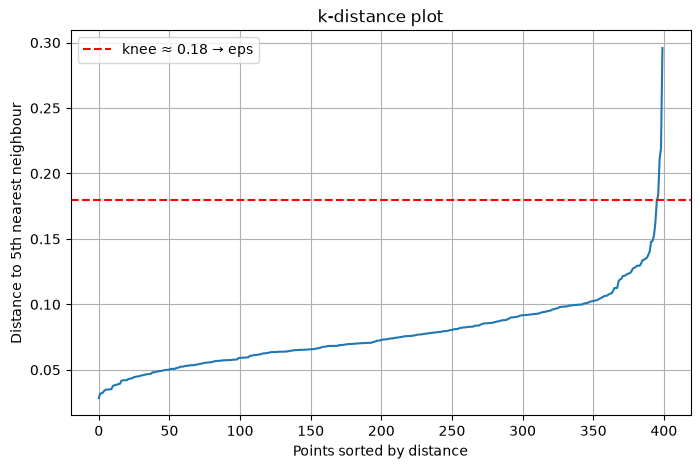

In [8]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_moons)
distances, _ = nn.kneighbors(X_moons)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.axhline(0.18, color="red", linestyle="--", label="knee ≈ 0.18 → eps")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbour")
plt.title("k-distance plot")
plt.legend(); plt.show()

### 2.3 Sensitivity to ε and minPts

DBSCAN's result depends heavily on its two parameters. Rules of thumb:
- `min_samples` ≥ number of dimensions + 1 (the original paper used 4 for 2-D; use larger values for noisy data)
- Then pick `eps` from the k-distance knee

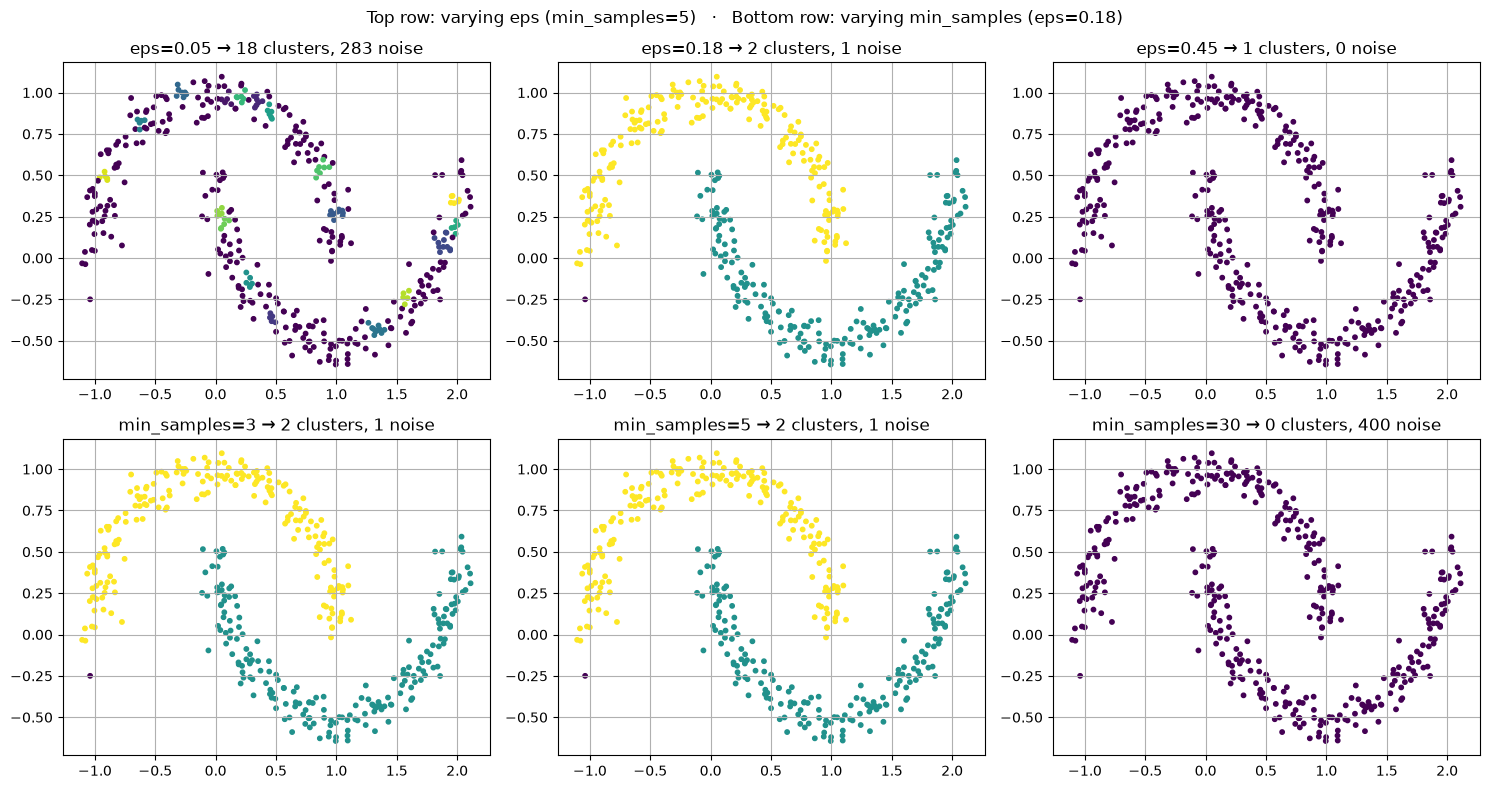

In [9]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, eps in zip(axes[0], [0.05, 0.18, 0.45]):
    lab = DBSCAN(eps=eps, min_samples=5).fit_predict(X_moons)
    n_c = len(set(lab)) - (1 if -1 in lab else 0)
    ax.scatter(*X_moons.T, c=lab, cmap="viridis", s=10)
    ax.set_title(f"eps={eps} → {n_c} clusters, {(lab==-1).sum()} noise")
for ax, mp in zip(axes[1], [3, 5, 30]):
    lab = DBSCAN(eps=0.18, min_samples=mp).fit_predict(X_moons)
    n_c = len(set(lab)) - (1 if -1 in lab else 0)
    ax.scatter(*X_moons.T, c=lab, cmap="viridis", s=10)
    ax.set_title(f"min_samples={mp} → {n_c} clusters, {(lab==-1).sum()} noise")
plt.suptitle("Top row: varying eps (min_samples=5)   ·   Bottom row: varying min_samples (eps=0.18)")
plt.tight_layout(); plt.show()

# Takeaway: eps too small -> everything is noise; eps too big -> clusters merge.

### 2.4 Free outlier detection

Noise points (`-1`) are outliers by definition — this is DBSCAN's superpower for fraud/anomaly detection.

In [ ]:
# Add some far-away outliers to the moons
outliers = np.array([[2.5, 1.5], [-1.5, -1.0], [2.8, -0.8], [-1.2, 1.4]])
X_out = np.vstack([X_moons, outliers])

lab = DBSCAN(eps=0.18, min_samples=5).fit_predict(X_out)
is_noise = lab == -1

plt.scatter(*X_out[~is_noise].T, c=lab[~is_noise], cmap="viridis", s=15, label="clustered")
plt.scatter(*X_out[is_noise].T, c="red", marker="x", s=80, linewidths=2, label="noise / anomaly")
plt.title("DBSCAN flags outliers automatically")
plt.legend(); plt.show()

print(f"Flagged {is_noise.sum()} anomalies out of {len(X_out)} points")

---
## Part 3 — Principal Component Analysis (PCA)

### 3.1 PCA from scratch with NumPy

The five steps from the slides:
1. **Standardise** the data
2. **Covariance matrix** $C = \frac{1}{n-1} X^{\top} X$
3. **Eigen-decompose** C → eigenvectors (directions) + eigenvalues (variance along each)
4. **Rank & select** the top-k eigenvectors
5. **Project**: $Z = X W$

In [ ]:
iris = load_iris()
X_iris = iris.data                       # (150, 4)
feature_names = iris.feature_names
print("Original shape:", X_iris.shape)

# Step 1: standardise
X_std = StandardScaler().fit_transform(X_iris)

# Step 2: covariance matrix (4 x 4)
cov = np.cov(X_std, rowvar=False)
print("\nCovariance matrix:\n", cov.round(2))

# Step 3: eigen-decomposition (eigh = for symmetric matrices)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Step 4: sort descending by eigenvalue, keep top 2
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
W = eigenvectors[:, :2]                  # (4, 2) projection matrix

explained_ratio = eigenvalues / eigenvalues.sum()
print("\nExplained variance ratio:", explained_ratio.round(4))
print(f"PC1 + PC2 capture {explained_ratio[:2].sum():.1%} of the variance")

# Step 5: project 4-D -> 2-D
Z_scratch = X_std @ W
print("\nProjected shape:", Z_scratch.shape)

### 3.2 Verify against scikit-learn

Same numbers (up to a possible sign flip per component — eigenvector direction is arbitrary).

In [ ]:
pca = PCA(n_components=2)
Z_sk = pca.fit_transform(X_std)

print("sklearn explained variance ratio:", pca.explained_variance_ratio_.round(4))
print("scratch explained variance ratio:", explained_ratio[:2].round(4))

# Compare projections, allowing for sign flips
match = all(np.allclose(Z_sk[:, i], Z_scratch[:, i]) or np.allclose(Z_sk[:, i], -Z_scratch[:, i])
            for i in range(2))
print("Projections match:", match)

### 3.3 Scree plot — how many components to keep?

In [ ]:
pca_full = PCA().fit(X_std)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, ax = plt.subplots()
ax.bar(range(1, 5), evr, alpha=0.7, label="Individual")
ax.plot(range(1, 5), cum, "-o", color="black", label="Cumulative")
ax.axhline(0.95, color="red", linestyle="--", label="95% threshold")
ax.set_xticks(range(1, 5), [f"PC{i}" for i in range(1, 5)])
ax.set_ylabel("Explained variance ratio")
ax.set_title("Scree plot — Iris")
ax.legend(); plt.show()

# Shortcut: let sklearn pick the number of components for a variance target
pca_95 = PCA(n_components=3).fit(X_std) # 90%
print(f"Components needed for 95% variance: {pca_95.n_components_}")

### 3.4 Visualise: 4-D Iris in 2-D

PCA never saw the species labels — we colour by species only to *check* that structure survived the compression.

In [ ]:
plt.figure(figsize=(8, 5.5))
for target, name in enumerate(iris.target_names):
    mask = iris.target == target
    plt.scatter(Z_sk[mask, 0], Z_sk[mask, 1], s=30, label=name, alpha=0.8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
plt.title("Iris projected onto its first two principal components")
plt.legend(); plt.show()

### 3.5 What did we lose? Reconstruction error

`inverse_transform` maps the 2-D projection back to 4-D. The gap between original and reconstruction is exactly the variance we discarded.

In [ ]:
X_reconstructed = pca.inverse_transform(Z_sk)
mse = np.mean((X_std - X_reconstructed) ** 2)
print(f"Mean squared reconstruction error: {mse:.4f}")
print(f"Discarded variance (PC3+PC4):      {evr[2:].sum():.4f}  <- matches!")

### 3.6 Which original features drive each component?

Component loadings tell you what each PC "means". Useful when presenting to stakeholders.

In [ ]:
loadings = pd.DataFrame(pca.components_.T,
                        index=feature_names,
                        columns=["PC1", "PC2"]).round(3)
print(loadings)
# PC1 loads on petal length/width + sepal length -> overall flower size
# PC2 is dominated by sepal width

---
## Part 4 — Mini-Project: Customer Segmentation (K-Means + PCA together)

A realistic workflow on synthetic "mall customer" data with 5 features:
**scale → choose k → cluster → reduce to 2-D for visualisation → profile the segments**.

In [ ]:
# Synthetic customer base with 3 hidden behaviour patterns
rng = np.random.RandomState(7)
n_per = 120

seg_a = np.c_[rng.normal(30, 5, n_per),  rng.normal(35, 8, n_per),   # young, modest income
              rng.normal(75, 10, n_per), rng.normal(18, 4, n_per),   # high spend, frequent visits
              rng.normal(2, 1, n_per)]                               # few support calls
seg_b = np.c_[rng.normal(45, 6, n_per),  rng.normal(85, 12, n_per),  # mid-age, high income
              rng.normal(45, 10, n_per), rng.normal(8, 3, n_per),
              rng.normal(3, 1.2, n_per)]
seg_c = np.c_[rng.normal(60, 7, n_per),  rng.normal(50, 10, n_per),  # older, mid income
              rng.normal(20, 8, n_per),  rng.normal(3, 1.5, n_per),  # low spend, rare visits
              rng.normal(7, 2, n_per)]                               # many support calls

cols = ["age", "annual_income_k", "spending_score", "visits_per_month", "support_calls"]
df = pd.DataFrame(np.vstack([seg_a, seg_b, seg_c]).clip(min=0), columns=cols)
df = df.sample(frac=1, random_state=0).reset_index(drop=True)   # shuffle: no labels!
df.head()

In [ ]:
# 1) Scale
X_cust = StandardScaler().fit_transform(df)

# 2) Choose k with the silhouette score
scores = {k: silhouette_score(X_cust, KMeans(k, n_init=10, random_state=0).fit_predict(X_cust))
          for k in range(2, 8)}
print({k: round(v, 3) for k, v in scores.items()})
best_k = max(scores, key=scores.get)
print("Chosen k:", best_k)

# 3) Cluster
km_cust = KMeans(n_clusters=best_k, n_init=10, random_state=0)
df["segment"] = km_cust.fit_predict(X_cust)

# 4) PCA to 2-D purely for the plot
Z2 = PCA(n_components=2).fit_transform(X_cust)
plt.figure(figsize=(8, 5.5))
plt.scatter(Z2[:, 0], Z2[:, 1], c=df["segment"], cmap="viridis", s=20)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"Customer segments (k = {best_k}) visualised via PCA")
plt.show()

In [ ]:
# 5) Profile each segment: the centroids in original units are the story you tell the business
profile = df.groupby("segment")[cols].mean().round(1)
profile["n_customers"] = df["segment"].value_counts().sort_index()
profile
# e.g. "young high-spenders", "affluent moderates", "older low-engagement / high-support"
# -> different marketing / retention strategies for each

---
## Exercises

1. **K-Means restarts** — run `kmeans_scratch` with `seed=1, 2, 3, ...` on `X`. Do you always get the same clusters? Compare the final inertia of each run (compute WCSS yourself). Relate this to why sklearn defaults to `n_init=10`.
2. **Elbow on hard data** — generate `make_blobs(centers=7, cluster_std=2.5)` and apply the elbow + silhouette methods. Is the answer still obvious? What does that teach about real data?
3. **DBSCAN on blobs with varying density** — create two blobs with `cluster_std=[0.4, 2.5]`. Can a single `eps` handle both? (This limitation motivates HDBSCAN — read about it.)
4. **PCA before clustering** — on the customer data, cluster using only the first 2 principal components instead of all 5 scaled features. Do the segment assignments change much? (Compare with `pd.crosstab`.)
5. **Digits challenge** — load `sklearn.datasets.load_digits()` (64 dimensions). Reduce to 2-D with PCA and scatter-plot coloured by the true digit. How well are the digits separated? How many components do you need for 95% variance?
6. *(Stretch)* Implement the **silhouette score for a single point** from its definition and verify it against `sklearn.metrics.silhouette_samples`.